# 1. Aggregation 
This notebook does the following:
- aggregate kNDVI time series per vegetation type
- remove seasonality for these time series
- compute resilience, resistance and recovery from these time series
- aggregate predictor variables per vegetation type as well
- unify in one dataframe

This is done for only one event in this notebook. Te automated process for all events is found in *analysis_execution.py*.



#### Considerations
- for steady state computatuon, i have to limit the selection of events to the ones that are not within 3 years (3*365) of the edges from the tempral coverage of kndvi data -> loss of  more events
- maybe i should not remove seasonality at all from kndiv time series
- do i use mean, median, min or max to aggregate kndvi time series?

In [2]:
# Standard libraries
import pandas as pd
import numpy as np
import xarray as xr

# Handling files
import requests
import zipfile
import tempfile
import io
import os
import glob

# Acces APIs
from xcube.core.store import new_data_store

# Plotting  
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Handling dates
import datetime
from datetime import timedelta

# Import own functions
from utils import event_sampling as es
from utils import event_visualization as ev
from utils import event_analysis
#from utils.event_analysis import apply_stl_decomposition # Not yet defined

# Analysis
from statsmodels.tsa.seasonal import STL

import importlib
importlib.reload(event_analysis)

<module 'utils.event_analysis' from '/Users/georgbrandt/Desktop/STUDIUM/Masterarbeit/repository/utils/event_analysis.py'>

## 1.1 Load data
- kNDVI
- event summary
- event cube
- land mask
- land cover

### kNDVI array

URL: 'https://data.rsc4earth.de/download/EarthSystemDataCube/v3.0.1/esdc-8d-0.25deg-1x720x1440-3.0.1.zarr/'

In [3]:
# Import kNDVI dataset
path = 'data/esdc_subset.zarr'
ds_esdc = xr.open_zarr(path)

# Select kNDVI
kndvi = ds_esdc['kndvi']

In [4]:
# Multiply kndvi by weights per latitude
kndvi = event_analysis.apply_cosine_weighting(kndvi)

### Event summary dataframe

In [60]:
# URL
url_chd_summary = "https://zenodo.org/records/14884254/files/MergedEventStats_landonly_int.csv.zip?download=1"

# Download the ZIP file
response = requests.get(url_chd_summary)
response.raise_for_status()

# Unzip the content
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as f:
        df_chd_summary = pd.read_csv(f)

# Create new column 'duration_days' with numeric values
df_chd_summary['duration_days'] = df_chd_summary['duration'].str.extract(r'(\d+)').astype(int)

# Convert start_time and end_time to datetime
df_chd_summary['start_time'] = pd.to_datetime(df_chd_summary['start_time'])
df_chd_summary['end_time'] = pd.to_datetime(df_chd_summary['end_time'])

# Filter dataframe for event duration
df_chd_filtered = df_chd_summary[df_chd_summary['duration_days'] >= 18] 

# Filter dataframe for period of ESDC kndvi data (2 year edges)
df_chd_filtered = df_chd_filtered[
    (df_chd_filtered['start_time'].dt.year >= 2002) &
    (df_chd_filtered['start_time'].dt.year <= 2019) &
    (df_chd_filtered['end_time'].dt.year >= 2002) &
    (df_chd_filtered['end_time'].dt.year <= 2019)
]

print(len(df_chd_filtered))

# Show DataFrame 
df_chd_filtered.sort_values('duration_days', ascending=False).head(10)


189


,label,start_time,end_time,longitude_min,longitude_max,latitude_min,latitude_max,t2mmax_mean,t2mmax_min,t2mmax_max,...,compound,land_share,inth,intd30,intd90,intd180,volume,duration,area,duration_days
10,105411,2016-02-27,2016-05-20,92.75,118.25,3.00,23.50,38.429633,29.907460,45.535502,...,100.0,100.0,16248.457214,10882.885354,11231.448425,4240.130612,22975.648359,84 days,273.519623,84
2247,100731,2015-07-14,2015-09-16,286.00,287.50,18.25,18.50,32.880938,29.240437,36.768260,...,100.0,100.0,218.550028,139.169701,181.245710,62.101517,304.527434,65 days,4.685037,65
178,104887,2016-02-09,2016-04-11,281.50,289.25,6.75,11.00,36.907783,22.837075,43.576030,...,100.0,100.0,2804.125332,957.145596,2107.004000,68.015374,3891.942409,63 days,61.776864,63
5813,109935,2017-01-27,2017-03-28,281.50,284.25,-14.75,-9.00,30.171803,27.822229,32.105410,...,100.0,100.0,63.215312,45.751063,38.967732,31.212608,85.665001,61 days,1.404344,61
21,86754,2011-07-15,2011-09-06,257.50,268.50,25.25,38.75,39.917825,29.952395,44.899790,...,100.0,100.0,10715.279400,7707.308031,7458.921376,5892.946581,17479.844032,54 days,323.700815,54
2383,97552,2014-08-15,2014-10-07,237.50,248.25,24.75,38.00,33.195644,27.402290,41.851355,...,100.0,100.0,173.154032,13.869059,76.569025,222.459604,279.819932,54 days,5.181851,54
6754,107867,2016-07-22,2016-09-13,321.75,340.75,65.75,77.50,11.604721,5.434857,19.997050,...,100.0,100.0,41.709392,40.295264,6.090612,0.285918,68.632860,54 days,1.270979,54
3,104409,2016-01-20,2016-03-13,0.00,359.75,-0.25,11.00,37.855397,25.982071,44.140147,...,100.0,100.0,24790.693774,19095.290823,18766.811721,306.037278,38512.666189,54 days,713.197522,54
2,83007,2010-07-02,2010-08-21,4.50,64.50,36.00,65.50,35.294501,21.937143,46.318790,...,100.0,100.0,66906.175092,68960.197766,36294.144024,11858.191820,87107.659248,51 days,1707.993319,51
39,107547,2016-07-02,2016-08-21,55.75,98.00,62.25,74.50,27.641322,12.107263,33.150924,...,100.0,100.0,7851.432595,9672.583045,3667.564724,509.444570,11650.042910,51 days,228.432214,51


### Event cube dataset

In [6]:
# Open zarr dataset
ds_chd_labels = xr.open_zarr('data/temp_zarr_extracted/mergedlabels_ranked_pot0.01_ne0.1_cmp_S1_T3_1950_2023.zarr', consolidated=False)

### Land mask array

In [7]:
# Open with xarray
path_landmask = "data/GLDASp5_landmask_025d.nc4"
ds_landmask = xr.open_dataset(path_landmask)

# Open the right variable as land mask
landmask = ds_landmask['GLDAS_mask']

### Land cover array and translation dataframe
Either use [Land Cover Cube (0.027 degrees)](https://deepesdl.readthedocs.io/en/latest/datasets/LC-1x2025x2025-2-0-0-levels/) or [GLDAS Dominant Vegetation (NOAH3.6, 1 degree)](https://ldas.gsfc.nasa.gov/gldas/vegetation-class-mask).

In [8]:
# Open with xarray
path_veg = 'data/GLDASp5_domveg_NOAH3.6_025d.nc4'
ds_veg = xr.open_dataset(path_veg)

# Open the right variable
vegetation = ds_veg['GLDAS_domveg']

In [9]:
# Open class translation dataframe
df_translation = pd.read_csv("data/GLDA_veg_legend.csv", index_col=0)

## 1.2 Prepare data (from here on process has to be looped over all events)

- create event mask with land mask and label cube
- create event array with kndvi data array and event mask

### Event mask


In [10]:
# Determine event start and end
start_time_value = df_chd_filtered.loc[df_chd_filtered['label'] == 105411, 'start_time'].values[0]
end_time_value = df_chd_filtered.loc[df_chd_filtered['label'] == 105411, 'end_time'].values[0]

In [11]:
# Create event area mask 
event_mask_105411 = es.create_event_mask(105411, start_date=start_time_value, end_date=end_time_value, labelcube=ds_chd_labels, land_mask=landmask)

### Event array

In [12]:
# 2 years buffer
buffer = 2 * 365

# Create event array
kndvi_array_105411 = es.create_event_dataarray(kndvi, event_mask_105411, start_date=start_time_value, end_date=end_time_value, time_buffer=buffer)

## 1.3 Aggregate kNDVI time series per land cover type
This aggregation is for the time series, i.e. returns aggregated time series per land cover type.

In [13]:
df_105411_mean_kndvi_ts = event_analysis.aggregate_da_to_timeseries(kndvi_array_105411, vegetation, event_mask_105411, method='mean')

#### Visualisation of the aggregation

check if new function output (kndvi aggregation) and kndvi_array_preweighted are the same

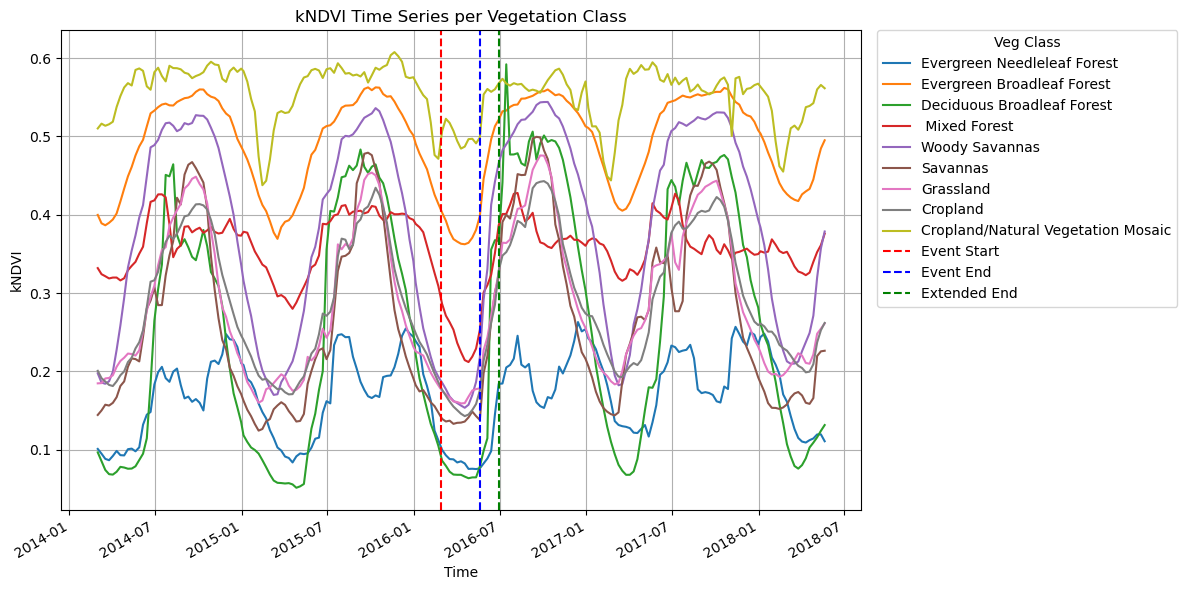

In [15]:
ev.plot_aggregated_ts(df_105411_mean_kndvi_ts, start_time_value, end_time_value, variable='kNDVI', df_translation=df_translation)

# 2. Calculate event statistics

Best hyperparameters found (already internally used by event_analysis.ts_decomposition()):
- inner_iter: 1
- outer_iter: 17
- seasonal: 155
- trend: 49

## 2.1 Check if there is another event in the time series
- load labelcube
- derive coordinates and dates from 2 year buffer prior and posterior
- query labelcube for these dates if there is another CHD record (longer than certain threshold, i.e. look for labels from filtered summary table)

In [93]:
events = df_chd_filtered['label']
events = [int(e) for e in events]

In [ ]:
other_events = es.check_for_other_events(start_date=start_time_value, end_date=end_time_value, event_mask=event_mask_105411, labelcube=ds_chd_labels, label=105411, events=events)

## 2.2 Calculation

In [16]:
# Calculate event statistics for deseasonalized data
df_stats_deseasonalized = event_analysis.calculate_event_stats(df_105411_mean_kndvi_ts, start_time_value, end_time_value)
df_stats_deseasonalized.T


,vpre,vdist,vpost,resilience,resistance,recovery,n_days_vdist,anomaly_strength,anomaly_strength_day
1.0,0.166728,0.075495,0.183459,1.100344,0.452800,-0.344836,75.0,-0.427531,-0.026721
2.0,0.490731,0.362378,0.504925,1.028924,0.738445,-0.595897,51.0,-0.529750,-0.033109
4.0,0.237652,0.063787,0.306350,1.289068,0.268404,-0.025842,59.0,-0.545575,-0.034098
5.0,0.365624,0.212054,0.362331,0.990992,0.579978,-0.429702,59.0,-1.178753,-0.073672
8.0,0.379866,0.153722,0.408027,1.074132,0.404673,-0.150369,51.0,-0.723936,-0.045246
9.0,0.258916,0.133197,0.293258,1.132637,0.514441,-0.354381,27.0,-0.743190,-0.046449
10.0,0.281882,0.159224,0.307585,1.091183,0.564859,-0.416497,43.0,-0.811519,-0.050720
12.0,0.284855,0.143057,0.307987,1.081204,0.502210,-0.337280,51.0,-0.583780,-0.036486
14.0,0.563060,0.484446,0.551073,0.978712,0.860381,-0.793754,43.0,-0.383938,-0.023996


## 3. Prepare predictors
This section aims to consolidate all predictor variables into one dataframe. This uncludes the following steps:
- loading of event characteristics (for spatiotempral masking)
- compute number of days affected
- loading of predictor variables (mostly from ESDC)
    - t2m mean, t2m max, t2m min
    - precipitation
    - soil moisture
    - evaporation
    - potential evaporation
    - SPEI
- stack dimensions of masked predictor variables, group by vegetation type
- create dataframe

Later, the target variables from step 2 will be added to this dataframe.

### 3.1 Load variables


In [ ]:
# Load data arrays
t2m = ds_esdc['air_temperature_2m']
t2mmin = ds_esdc['min_air_temperature_2m']
t2mmax = ds_esdc['max_air_temperature_2m']
prec = ds_esdc['precipitation_era5']
soil_moist = ds_esdc['root_moisture']
evap = ds_esdc['evaporation']
evap_pot = ds_esdc['potential_evaporation']

# Cosine weighting
t2m_w = event_analysis.apply_cosine_weighting(t2m)
t2mmin_w = event_analysis.apply_cosine_weighting(t2mmin)
t2mmax_w = event_analysis.apply_cosine_weighting(t2mmax)
prec_w = event_analysis.apply_cosine_weighting(prec)
soil_moist_w = event_analysis.apply_cosine_weighting(soil_moist)
evap_w = event_analysis.apply_cosine_weighting(evap)
evap_pot_w = event_analysis.apply_cosine_weighting(evap_pot)

# Create event arrays
t2m_array_105411 = es.create_event_dataarray(d_array = t2m, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value)
t2mmin_array_105411 = es.create_event_dataarray(d_array = t2mmin, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value)
t2mmax_array_105411 = es.create_event_dataarray(d_array = t2mmax, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value)

# Cosine weighted versions
t2m_w_array_105411 = es.create_event_dataarray(d_array = t2m_w, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value, time_buffer=buffer)
t2mmin_w_array_105411 = es.create_event_dataarray(d_array = t2mmin_w, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value, time_buffer=buffer)
t2mmax_w_array_105411 = es.create_event_dataarray(d_array = t2mmax_w, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value, time_buffer=buffer)
prec_w_array_105411 = es.create_event_dataarray(d_array = prec_w, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value, time_buffer=buffer)
soil_moist_w_array_105411 = es.create_event_dataarray(d_array = soil_moist_w, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value, time_buffer=buffer)
evap_w_array_105411 = es.create_event_dataarray(d_array = evap_w, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value, time_buffer=buffer)
evap_pot_w_array_105411 = es.create_event_dataarray(d_array = evap_pot_w, event_mask = event_mask_105411, start_date=start_time_value, end_date=end_time_value, time_buffer=buffer)

### 3.2 Compute and aggregate predictors
#### Number of days affected

In [18]:
event_count_105411 = event_analysis.calculate_n_days_affected(start_time_value, end_time_value, event_mask_105411, event_label=105411, ds_label=ds_chd_labels) # Already tailored to specific event

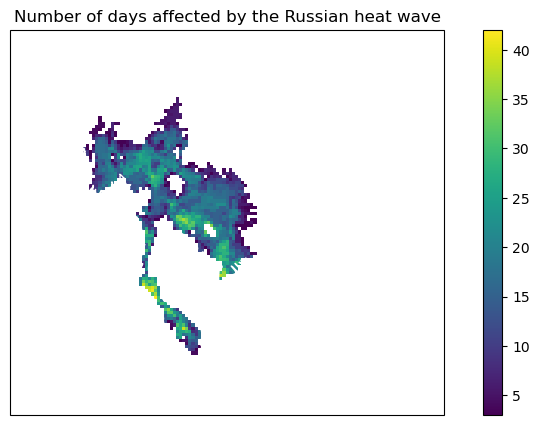

In [19]:
# Plot the event count array
plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
event_count_105411.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', add_colorbar=True)
ax.set_title("Number of days affected by the Russian heat wave")
ax.coastlines(color='white')
ax.set_extent([88, 123, -2, 28])
plt.show()

### 3.3 Compute anomaly score 


In [21]:
df_105411_mean_t2m_ts = event_analysis.aggregate_da_to_timeseries(t2m_w_array_105411, vegetation, event_mask_105411, method='mean')
df_105411_mean_t2mmin_ts = event_analysis.aggregate_da_to_timeseries(t2mmin_w_array_105411, vegetation, event_mask_105411, method='mean')
df_105411_mean_t2mmax_ts = event_analysis.aggregate_da_to_timeseries(t2mmax_w_array_105411, vegetation, event_mask_105411, method='mean')
df_105411_mean_prec_ts = event_analysis.aggregate_da_to_timeseries(prec_w_array_105411, vegetation, event_mask_105411, method='mean')
df_105411_mean_soil_moist_ts = event_analysis.aggregate_da_to_timeseries(soil_moist_w_array_105411, vegetation, event_mask_105411, method='mean')
df_105411_mean_evap_ts = event_analysis.aggregate_da_to_timeseries(evap_w_array_105411, vegetation, event_mask_105411, method='mean')
df_105411_mean_evap_pot_ts = event_analysis.aggregate_da_to_timeseries(evap_pot_w_array_105411, vegetation, event_mask_105411, method='mean')

Decompose

In [23]:
df_105411_mean_t2m_resid = event_analysis.ts_decomposition(df_105411_mean_t2m_ts)
df_105411_mean_t2mmin_resid = event_analysis.ts_decomposition(df_105411_mean_t2mmin_ts)
df_105411_mean_t2mmax_resid = event_analysis.ts_decomposition(df_105411_mean_t2mmax_ts)
df_105411_mean_prec_resid = event_analysis.ts_decomposition(df_105411_mean_prec_ts)
df_105411_mean_soil_moist_resid = event_analysis.ts_decomposition(df_105411_mean_soil_moist_ts)
df_105411_mean_evap_resid = event_analysis.ts_decomposition(df_105411_mean_evap_ts)
df_105411_mean_evap_pot_resid = event_analysis.ts_decomposition(df_105411_mean_evap_pot_ts)

Sum up area under curve for event period + 50 % time bufer before event. By default, this function normalizes the anomaly strength by dividing the sum by the number of data points. If only the sum is searched, set normalized=False.

In [45]:
t2m_anomalies_105411 = event_analysis.calculate_predictor_anomaly(df_105411_mean_t2m_resid, start_time_value, end_time_value)
t2mmin_anomalies_105411 = event_analysis.calculate_predictor_anomaly(df_105411_mean_t2mmin_resid, start_time_value, end_time_value)
t2mmax_anomalies_105411 = event_analysis.calculate_predictor_anomaly(df_105411_mean_t2mmax_resid, start_time_value, end_time_value)
prec_anomalies_105411 = event_analysis.calculate_predictor_anomaly(df_105411_mean_prec_resid, start_time_value, end_time_value)
soil_moist_anomalies_105411 = event_analysis.calculate_predictor_anomaly(df_105411_mean_soil_moist_resid, start_time_value, end_time_value)
evap_anomalies_105411 = event_analysis.calculate_predictor_anomaly(df_105411_mean_evap_resid, start_time_value, end_time_value)
evap_pot_anomalies_105411 = event_analysis.calculate_predictor_anomaly(df_105411_mean_evap_pot_resid, start_time_value, end_time_value)

### 4. Put together target values and predictors


In [145]:
# Aggregated values per vegetation over event period
event_count_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation, 
                                                                event_mask=event_mask_105411, 
                                                                data_array=event_count_105411, 
                                                                method='mean')
t2m_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=t2m_array_105411,
                                                   method='mean')
t2mmin_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=t2mmin_array_105411,
                                                   method='mean')
t2mmax_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=t2mmax_array_105411,
                                                   method='mean')
prec_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=prec_w_array_105411,
                                                   method='sum')
soil_moist_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=soil_moist_w_array_105411,
                                                   method='sum')
evap_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=evap_w_array_105411,
                                                   method='sum')
evap_pot_agg_105411 = event_analysis.aggregate_by_vegetation(vegetation=vegetation,
                                                   event_mask=event_mask_105411,
                                                   data_array=evap_pot_w_array_105411,
                                                   method='sum')

# Anomalies of predictors based on residuals

# Put series together as dataframe
df_105411 = pd.DataFrame({'n_days': event_count_agg_105411,
                           't2m': t2m_agg_105411,
                           't2mmin': t2mmin_agg_105411,
                           't2mmax': t2mmax_agg_105411,
                           'prec': prec_agg_105411,
                           'soil_moist': soil_moist_agg_105411,
                           'evap': evap_agg_105411,
                           'evap_pot': evap_pot_agg_105411,
                           't2m_anomaly': t2m_anomalies_105411,
                           't2mmin_anomaly': t2mmin_anomalies_105411,
                           't2mmax_anomaly': t2mmax_anomalies_105411,
                           'prec_anomaly': prec_anomalies_105411,
                           'evap_anomaly': evap_anomalies_105411,
                           'evap_pot_anomaly': evap_pot_anomalies_105411,
                           'other_event': other_events})

# Add event stats to dataframe
df_105411 = df_105411.join(df_stats_deseasonalized.T)

# Add column with event label
df_105411['event_label'] = 105411

# Use vegetation type and event label as multiindex
df_105411 = df_105411.set_index(['event_label', df_105411.index])

# Drop rows with NaN values
df_105411 = df_105411.dropna()

df_105411

n_days        t2m     t2mmin     t2mmax           prec  \
event_label                                                                   
105411      1.0   30.000000  27.139009  23.488594  32.088093    1297.243849   
            2.0   14.625683  25.553421  19.530460  33.274090  767753.440174   
            4.0   14.000000  28.390463  21.640602  37.605694     610.891217   
            5.0   22.909091  26.906374  21.098267  34.087883   10257.170589   
            8.0   12.722772  27.802845  21.251038  35.736954   77859.137738   
            9.0    6.000000  27.250563  19.970627  35.077591    1864.166048   
            10.0  12.533333  27.991474  21.056370  35.716660   13578.871370   
            12.0  16.261324  29.102619  23.028124  36.485764  451222.282055   
            14.0  26.500000  29.139164  23.059013  36.624947    2086.518966   

                    soil_moist           evap       evap_pot  t2m_anomaly  \
event_label                                                                 
105411      1.0      70.501347     471.054879     624.102418    16.531436   
            2.0   49114.308469  423273.666820  470014.952772    10.147660   
            4.0      55.278488     292.262556     548.104252    14.774430   
            5.0     840.869687    6567.435205    8242.985648    14.254598   
            8.0    6385.343997   45309.581043   57702.934600    17.035067   
            9.0     138.575205     821.707239    1141.986317     3.783296   
            10.0   1107.538352    6784.509676    9376.555188     9.600562   
            12.0  39571.023535  236916.180115  334211.067169    16.592041   
            14.0    172.366874    1227.720571    1280.912810    26.760815   

                  t2mmin_anomaly  ...  other_event      vpre     vdist  \
event_label                       ...                                    
105411      1.0         6.374134  ...        False  0.166728  0.075495   
            2.0         2.817016  ...        False  0.490731  0.362378   
            4.0        21.912534  ...        False  0.237652  0.063787   
            5.0         1.908041  ...        False  0.365624  0.212054   
            8.0         6.648713  ...        False  0.379866  0.153722   
            9.0       -15.585006  ...        False  0.258916  0.133197   
            10.0       -9.601226  ...        False  0.281882  0.159224   
            12.0        4.889104  ...        False  0.284855  0.143057   
            14.0       14.290374  ...        False  0.563060  0.484446   

                     vpost  resilience  resistance  recovery  n_days_vdist  \
event_label                                                                  
105411      1.0   0.183459    1.100344    0.452800 -0.344836          75.0   
            2.0   0.504925    1.028924    0.738445 -0.595897          51.0   
            4.0   0.306350    1.289068    0.268404 -0.025842          59.0   
            5.0   0.362331    0.990992    0.579978 -0.429702          59.0   
            8.0   0.408027    1.074132    0.404673 -0.150369          51.0   
            9.0   0.293258    1.132637    0.514441 -0.354381          27.0   
            10.0  0.307585    1.091183    0.564859 -0.416497          43.0   
            12.0  0.307987    1.081204    0.502210 -0.337280          51.0   
            14.0  0.551073    0.978712    0.860381 -0.793754          43.0   

                  anomaly_strength  anomaly_strength_day  
event_label                                               
105411      1.0          -0.427531             -0.026721  
            2.0          -0.529750             -0.033109  
            4.0          -0.545575             -0.034098  
            5.0          -1.178753             -0.073672  
            8.0          -0.723936             -0.045246  
            9.0          -0.743190             -0.046449  
            10.0         -0.811519             -0.050720  
            12.0         -0.583780             -0.036486  
            14.0         -0.383938     